# LinMNIST Classification

In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from dataset import LinMNIST
from torch.utils.data import DataLoader

from torchcdt.functional import rcdt

For reproducibility, we set a seed.

In [9]:
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

We load the LinMNIST dataset with 3 classes. Each class consists of 50 different affine transformations of a single template.

In [10]:
transform = transforms.RandomAffine(
    degrees=45,
    translate=(0.15, 0.15),
    scale=(0.85, 1.15),
    shear=(10, 10, 10, 10),
)

classes = torch.tensor([1, 5, 7])
num_classes = len(classes)
train_dataset = LinMNIST(
    train=True,
    num_templates_per_class=1,
    num_samples_per_template=50,
    transform=transform,
    classes=classes,
    shuffle=True,
)

We plot the first batch.

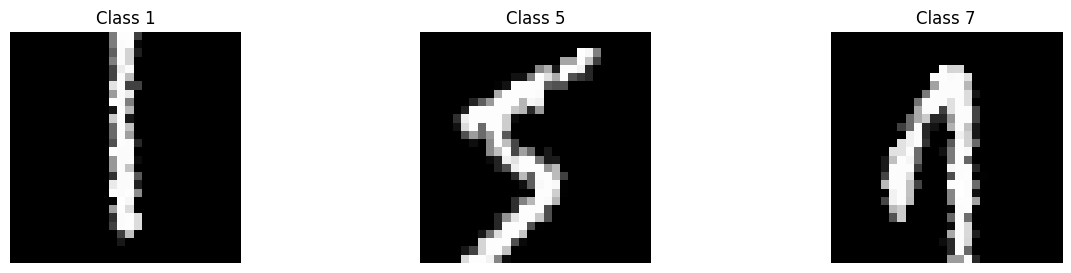

In [11]:
batch_size = int(1000)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
train_iter = iter(train_loader)
images_train, labels_train = next(train_iter)
fig, axs = plt.subplots(1, num_classes, figsize=(15, 3))
for i, class_ in enumerate(classes):
    idx = torch.where(labels_train == class_)[0][0]
    axs[i].imshow(images_train[idx].squeeze(), cmap="gray")
    axs[i].set_title(f"Class {class_}")
    axs[i].axis("off")
plt.show()

We define a simple Linear SVM parametrized via a single nn.Linear layer. We need to remap the labels to be between 0 and num_classes-1 for the loss function

In [12]:
img_feat = images_train[0].numel()
rcdt_feat = rcdt(images_train, circle=False)[0].numel()
mean_rcdt_feat = rcdt(images_train, normalization="mean", circle=False)[0].numel()
max_rcdt_feat = rcdt(images_train, normalization="max", circle=False)[0].numel()


class LinearSVM(nn.Module):
    def __init__(self, num_features):
        super(LinearSVM, self).__init__()
        self.num_features = num_features
        self.linear = nn.Linear(num_features, num_classes)

    def forward(self, x):
        x = x.reshape(-1, self.num_features)
        return self.linear(x)


mapping = torch.zeros(10, dtype=torch.long).to(device)
for i, class_ in enumerate(classes):
    mapping[class_] = i

num_epochs = 100

10-fold cross-validation in euclidean space. From hereinafter we use the ADAM optimizer and the hinge loss function.

In [13]:
test_accuracies = list()
for fold in range(10):
    loss_fn = nn.MultiMarginLoss(p=2)
    model = LinearSVM(num_features=img_feat).to(device)
    optimizer = torch.optim.Adam(model.parameters(), 1e-1)

    train_size = len(train_dataset) // 10
    train_data = torch.utils.data.Subset(
        train_dataset, list(range(fold * train_size, (fold + 1) * train_size))
    )
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)
    test_data = torch.utils.data.Subset(
        train_dataset,
        list(range(0, fold * train_size))
        + list(range((fold + 1) * train_size, len(train_dataset))),
    )
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    for i in range(num_epochs):
        for batch_img, batch_labels in train_loader:
            optimizer.zero_grad()
            pred = model(batch_img.to(device))
            # Compute loss between predicted and target labels
            loss_value = loss_fn(pred, mapping[batch_labels.to(device)])
            # Backward pass
            loss_value.backward()
            # Update model parameters
            optimizer.step()

    model.eval()
    with torch.no_grad():
        num_correct = 0
        for batch_img, batch_labels in test_loader:
            pred = model(batch_img.to(device))
            predicted_labels = torch.argmax(pred, dim=1)
            num_correct += (
                (predicted_labels == mapping[batch_labels.to(device)]).sum().item()
            )
        accuracy = num_correct / len(test_data)
        test_accuracies.append(accuracy)
    print(f"Fold {fold}: Test Accuracy: {accuracy * 100:.2f}%")

print(
    f"Classification in euclidean space completed with mean accuracy: {torch.mean(torch.tensor(test_accuracies)) * 100:.2f}%"
)


Fold 0: Test Accuracy: 65.19%
Fold 1: Test Accuracy: 69.63%
Fold 2: Test Accuracy: 70.37%
Fold 3: Test Accuracy: 68.89%
Fold 4: Test Accuracy: 72.59%
Fold 5: Test Accuracy: 58.52%
Fold 6: Test Accuracy: 66.67%
Fold 7: Test Accuracy: 79.26%
Fold 8: Test Accuracy: 70.37%
Fold 9: Test Accuracy: 73.33%
Classification in euclidean space completed with mean accuracy: 69.48%


10-fold cross-validation in R-CDT space.

In [14]:
test_accuracies = list()
for fold in range(10):
    loss_fn = nn.MultiMarginLoss(p=2)
    model = LinearSVM(num_features=rcdt_feat).to(device)
    optimizer = torch.optim.Adam(model.parameters(), 1e-1)

    train_size = len(train_dataset) // 10
    train_data = torch.utils.data.Subset(
        train_dataset, list(range(fold * train_size, (fold + 1) * train_size))
    )
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)
    test_data = torch.utils.data.Subset(
        train_dataset,
        list(range(0, fold * train_size))
        + list(range((fold + 1) * train_size, len(train_dataset))),
    )
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    for i in range(num_epochs):
        for batch_img, batch_labels in train_loader:
            optimizer.zero_grad()
            pred = model(rcdt(batch_img.to(device), circle=False))
            # Compute loss between predicted and target labels
            loss_value = loss_fn(pred, mapping[batch_labels.to(device)])
            # Backward pass
            loss_value.backward()
            # Update model parameters
            optimizer.step()

    model.eval()
    with torch.no_grad():
        num_correct = 0
        for batch_img, batch_labels in test_loader:
            pred = model(rcdt(batch_img.to(device), circle=False))
            predicted_labels = torch.argmax(pred, dim=1)
            num_correct += (
                (predicted_labels == mapping[batch_labels.to(device)]).sum().item()
            )
        accuracy = num_correct / len(test_data)
        test_accuracies.append(accuracy)
        print(f"Fold {fold}: Test Accuracy: {accuracy * 100:.2f}%")

print(
    f"Classification in R-CDT space completed with mean accuracy: {torch.mean(torch.tensor(test_accuracies)) * 100:.2f}%"
)

Fold 0: Test Accuracy: 82.96%
Fold 1: Test Accuracy: 72.59%
Fold 2: Test Accuracy: 80.74%
Fold 3: Test Accuracy: 79.26%
Fold 4: Test Accuracy: 82.96%
Fold 5: Test Accuracy: 80.00%
Fold 6: Test Accuracy: 68.15%
Fold 7: Test Accuracy: 80.00%
Fold 8: Test Accuracy: 81.48%
Fold 9: Test Accuracy: 68.15%
Classification in R-CDT space completed with mean accuracy: 77.63%


10-fold cross-validation in mean-normalized R-CDT space. I noticed that in this space, optimization is sensitive to learning rate and number of epochs.

In [15]:
test_accuracies = list()
for fold in range(10):
    loss_fn = nn.MultiMarginLoss(p=2)
    model = LinearSVM(num_features=mean_rcdt_feat).to(device)
    optimizer = torch.optim.Adam(model.parameters(), 1e-1)

    train_size = len(train_dataset) // 10
    train_data = torch.utils.data.Subset(
        train_dataset, list(range(fold * train_size, (fold + 1) * train_size))
    )
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)
    test_data = torch.utils.data.Subset(
        train_dataset,
        list(range(0, fold * train_size))
        + list(range((fold + 1) * train_size, len(train_dataset))),
    )
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    for i in range(num_epochs):
        for batch_img, batch_labels in train_loader:
            optimizer.zero_grad()
            pred = model(rcdt(batch_img.to(device), normalization="mean", circle=False))
            # Compute loss between predicted and target labels
            loss_value = loss_fn(pred, mapping[batch_labels.to(device)])
            # Backward pass
            loss_value.backward()
            # Update model parameters
            optimizer.step()

    model.eval()
    with torch.no_grad():
        num_correct = 0
        for batch_img, batch_labels in test_loader:
            pred = model(rcdt(batch_img.to(device), normalization="mean", circle=False))
            predicted_labels = torch.argmax(pred, dim=1)
            num_correct += (
                (predicted_labels == mapping[batch_labels.to(device)]).sum().item()
            )
        accuracy = num_correct / len(test_data)
        test_accuracies.append(accuracy)
        print(f"Fold {fold}: Test Accuracy: {accuracy * 100:.2f}%")

print(
    f"Classification in mean-normalized R-CDT space completed with mean accuracy: {torch.mean(torch.tensor(test_accuracies)) * 100:.2f}%"
)

Fold 0: Test Accuracy: 91.11%
Fold 1: Test Accuracy: 71.85%
Fold 2: Test Accuracy: 78.52%
Fold 3: Test Accuracy: 88.15%
Fold 4: Test Accuracy: 85.93%
Fold 5: Test Accuracy: 84.44%
Fold 6: Test Accuracy: 77.78%
Fold 7: Test Accuracy: 68.89%
Fold 8: Test Accuracy: 74.81%
Fold 9: Test Accuracy: 71.85%
Classification in mean-normalized R-CDT space completed with mean accuracy: 79.33%


10-fold cross-validation in mean-normalized R-CDT space. 

In [16]:
test_accuracies = list()
for fold in range(10):
    loss_fn = nn.MultiMarginLoss(p=2)
    model = LinearSVM(num_features=max_rcdt_feat).to(device)
    optimizer = torch.optim.Adam(model.parameters(), 1e-1)

    train_size = len(train_dataset) // 10
    train_data = torch.utils.data.Subset(
        train_dataset, list(range(fold * train_size, (fold + 1) * train_size))
    )
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)
    test_data = torch.utils.data.Subset(
        train_dataset,
        list(range(0, fold * train_size))
        + list(range((fold + 1) * train_size, len(train_dataset))),
    )
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    for i in range(num_epochs):
        for batch_img, batch_labels in train_loader:
            optimizer.zero_grad()
            pred = model(rcdt(batch_img.to(device), normalization="max", circle=False))
            # Compute loss between predicted and target labels
            loss_value = loss_fn(pred, mapping[batch_labels.to(device)])
            # Backward pass
            loss_value.backward()
            # Update model parameters
            optimizer.step()

    model.eval()
    with torch.no_grad():
        num_correct = 0
        for batch_img, batch_labels in test_loader:
            pred = model(rcdt(batch_img.to(device), normalization="max", circle=False))
            predicted_labels = torch.argmax(pred, dim=1)
            num_correct += (
                (predicted_labels == mapping[batch_labels.to(device)]).sum().item()
            )
        accuracy = num_correct / len(test_data)
        test_accuracies.append(accuracy)
        print(f"Fold {fold}: Test Accuracy: {accuracy * 100:.2f}%")

print(
    f"Classification in max-normalized R-CDT space completed with mean accuracy: {torch.mean(torch.tensor(test_accuracies)) * 100:.2f}%"
)


Fold 0: Test Accuracy: 95.56%
Fold 1: Test Accuracy: 100.00%
Fold 2: Test Accuracy: 100.00%
Fold 3: Test Accuracy: 100.00%
Fold 4: Test Accuracy: 97.04%
Fold 5: Test Accuracy: 98.52%
Fold 6: Test Accuracy: 100.00%
Fold 7: Test Accuracy: 99.26%
Fold 8: Test Accuracy: 96.30%
Fold 9: Test Accuracy: 97.04%
Classification in max-normalized R-CDT space completed with mean accuracy: 98.37%
